# Your mosaic in a Game of Life simulator

A mosaic is not just a picture of a still life: it *is* one. This notebook exports the pattern to a `.cells` file for [Golly](https://golly.sourceforge.io/), the standard Game of Life simulator, where it stays frozen generation after generation, until a glider flies in and the whole portrait starts to unravel.

Only the still life is exported. The coloured background (the elementary cellular automaton) is decoration and would not be stable.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from gol_mosaics import GollyExporter, MosaicGenerator
from gol_mosaics.life import is_still_life, life_step

from pathlib import Path

# The repository root, wherever Jupyter was started from
REPO = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "pyproject.toml").exists())


## Make a mosaic, and keep its cells

`return_arrays=True` returns the still life itself (a 0/1 array, one entry per cell) next to the rendered image.

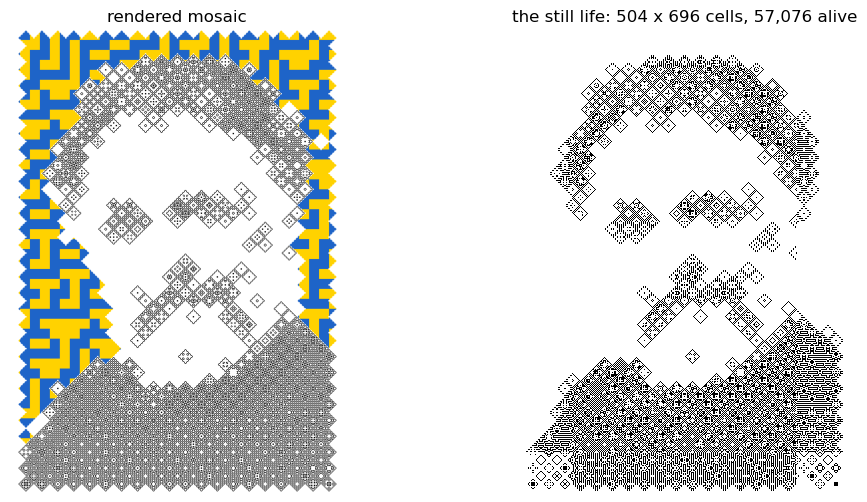

In [2]:
image = Image.open(REPO / 'input/images/john.png')

generator = MosaicGenerator(level=4, grid_size=40, eca_rule=30)
picture, cells, background = generator.generate_from_pil(
    image, seed=1, return_arrays=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(picture)
axes[0].set_title('rendered mosaic')
axes[1].imshow(cells, cmap='binary', interpolation='nearest')
axes[1].set_title(f'the still life: {cells.shape[1]} x {cells.shape[0]} cells, '
                  f'{int(cells.sum()):,} alive')
for ax in axes:
    ax.axis('off')
plt.show()

## Check that it is a still life

One step of the Game of Life must leave every cell as it is.

In [3]:
print('still life:', is_still_life(cells))

still life: True


## Export, with a glider

`add_glider` places a glider in one corner, heading into the grid. In Golly, press play: the portrait holds still until the glider hits it.

In [4]:
path = REPO / 'output/golly/my_mosaic.cells'
GollyExporter.export_to_cells(cells, str(path), add_glider='bottom right')
print(f'saved {path.relative_to(REPO).as_posix()} ({path.stat().st_size / 1024:.0f} kB)')

saved output/golly/my_mosaic.cells (343 kB)


## What the glider does

The same collision, simulated here: a glider aimed at the middle of the portrait from just outside it. The portrait stays frozen while the glider approaches; the moment they touch, the still life starts to come apart.

(The whole pattern has to be simulated. A cropped piece of a still life is not a still life: its cut edges fall apart on their own.)

the glider reaches the portrait after 171 generations


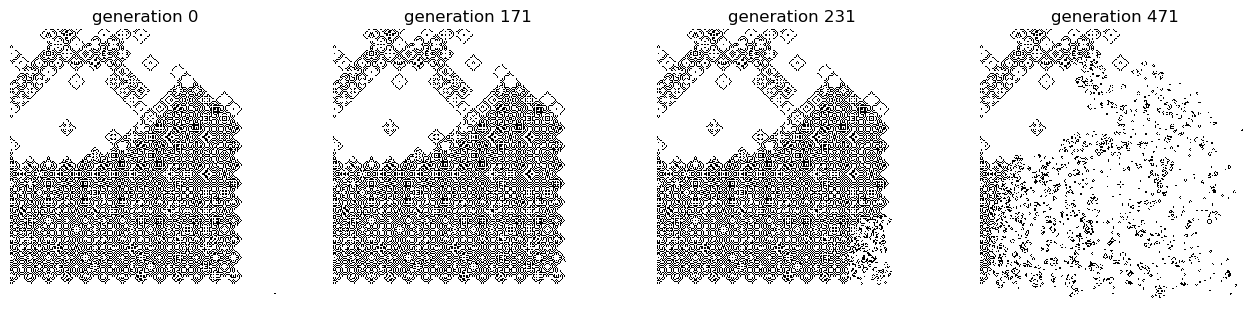

In [5]:
glider = np.rot90(np.array([[0, 1, 0], [0, 0, 1], [1, 1, 1]]), 2)  # heads up and left

# Aim at the middle of the portrait from just outside its bottom-right edge
rows, cols = np.nonzero(cells)
ci, cj = int(rows.mean()), int(cols.mean())
k = max(rows.max() - ci, cols.max() - cj) + 12
pad = k + 10
world = np.pad(cells, pad)
gi, gj = ci + pad + k, cj + pad + k
world[gi:gi + 3, gj:gj + 3] = glider

population = world.sum()
frames, hit, t = {0: world}, None, 0
while hit is None or t < hit + 300:
    world = life_step(world)
    t += 1
    if hit is None and world.sum() != population:
        hit = t  # the first change beyond the glider: impact
    if hit is not None and t in (hit, hit + 60, hit + 300):
        frames[t] = world
print(f'the glider reaches the portrait after {hit} generations')

window = (slice(gi - 4 * k // 3, gi + 8), slice(gj - 4 * k // 3, gj + 8))
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (t, frame) in zip(axes, frames.items()):
    ax.imshow(frame[window], cmap='binary', interpolation='nearest')
    ax.set_title(f'generation {t}')
    ax.axis('off')
plt.show()